# Applied Exercise 5 - Validation Set Approach for Logistic Regression

#### Objective of this exercise is to use the Default data set to estimate the test error of logistic regression models using the validation set approach

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from ISLP import load_data

from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error

In [2]:
Default = load_data("Default")

# Convert categorical response to binary
Default["default"] = (Default["default"] == "Yes").astype(int)
Default["student"] = (Default["student"] == "Yes").astype(int)

In [3]:
X = Default[["income", "balance"]]
y = Default["default"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print("="*60)
print("Logistic Regression")
print("="*60)

print("Intercept:", model.intercept_[0])
print("Coefficients:")
coef = pd.DataFrame({"Variable": X.columns, "Coefficient": model.coef_[0]})
print(coef)

Logistic Regression
Intercept: -11.54046791864163
Coefficients:
  Variable  Coefficient
0   income     0.000021
1  balance     0.005647


In [4]:
def validation_error(seed, predictors):
    X = Default[predictors]
    y = Default["default"]
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.5, random_state=seed)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_valid)[:,1]
    pred = (prob > 0.5).astype(int)
    error = np.mean(pred != y_valid)
    return error

In [5]:
print("\n" + "="*60)
print("Validation Set Error")
print("="*60)

error = validation_error(seed=1, predictors=["income","balance"])
print("Validation Error =", error)


Validation Set Error
Validation Error = 0.025


In [6]:
print("\n" + "="*60)
print("Three Different Splits")
print("="*60)

for seed in [1,2,3]:
    err = validation_error(seed, ["income","balance"])
    print(f"Seed {seed}: {err:.4f}")


Three Different Splits
Seed 1: 0.0250
Seed 2: 0.0248
Seed 3: 0.0248


In [7]:
print("\n" + "="*60)
print("Including Student")
print("="*60)

for seed in [1,2,3]:
    err = validation_error(seed, ["income","balance","student"])
    print(f"Seed {seed}: {err:.4f}")


Including Student
Seed 1: 0.0262
Seed 2: 0.0250
Seed 3: 0.0252


- Using the validation set approach with a 50-50 train-test split, the model achieved a validation error of 2.50%. This indicates that the logistic regression model correctly classified approximately 97.5% of the observations in the validation set, demonstrating good predictive performance.
- The estimated test errors are nearly identical across the three random splits. This suggests that the logistic regression model is stable and that the estimated prediction error is not highly sensitive to the particular training and validation sets selected. Minor differences are expected due to random sampling.
- Including the student variable does not reduce the validation error. In fact, the prediction error is almost identical and is slightly larger for some random splits. Therefore, there is little evidence that the student predictor provides additional predictive information once income and balance are already included in the model.

# Applied Exercise 6 - Estimating Logistic Regression Standard Errors using Bootstrap

#### Objective of this exercise is to compare methods for estimating the standard errors of logistic regression coefficients on the Default data set

In [8]:
np.random.seed(1)
Default = load_data("Default")
Default["default"] = (Default["default"] == "Yes").astype(int)

X = Default[["income", "balance"]]
X = sm.add_constant(X)
y = Default["default"]

glm = sm.GLM(y, X, family=sm.families.Binomial()).fit()

print(glm.summary())
print("\nStandard Errors")
print(glm.bse)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -789.48
Date:                Sat, 08 Aug 2026   Deviance:                       1579.0
Time:                        21:51:28   Pearson chi2:                 6.95e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.0

In [9]:
def boot_fn(data, index):
    sample = data.iloc[index]

    X = sample[["income", "balance"]]
    X = sm.add_constant(X)
    y = sample["default"]

    model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
    return model.params

B = 1000
boot_coef = np.zeros((B,3))
n = len(Default)

for i in range(B):
    index = np.random.choice(n, n, replace=True)
    boot_coef[i,:] = boot_fn(Default,index)

boot_coef = pd.DataFrame(boot_coef, columns=["const", "income", "balance"])

print("\n" + "="*60)
print("Bootstrap Standard Errors")
print("="*60)
print(boot_coef.std())


Bootstrap Standard Errors
const      0.448999
income     0.000005
balance    0.000233
dtype: float64


In [10]:
comparison = pd.DataFrame({"GLM Std Error": glm.bse, "Bootstrap Std Error": boot_coef.std()})

print("\n" + "="*60)
print("Comparison")
print("="*60)
print(comparison)


Comparison
         GLM Std Error  Bootstrap Std Error
const         0.434772             0.448999
income        0.000005             0.000005
balance       0.000227             0.000233


The bootstrap standard errors are very similar to those obtained from the GLM output. For the intercept, the bootstrap estimate (≈0.449) is close to the GLM estimate (≈0.435). Likewise, the bootstrap standard errors for income (≈0.000005) and balance (≈0.000233) are nearly identical to the GLM estimates. This indicates that the standard errors computed using the asymptotic GLM formula are reliable for this data set, and the bootstrap provides empirical confirmation of these estimates.

# Applied Exercise 7 - Leave-One-Out Cross Validation (Weekly Data)

#### Objective of this exercise is to use Leave-One-Out Cross Validation (LOOCV) to estimate the test error of a logistic regression model

In [11]:
Weekly = load_data("Weekly")
Weekly["Direction"] = (Weekly["Direction"] == "Up").astype(int)

print("="*60)
print("Logistic Regression using Lag1 and Lag2")
print("="*60)

X = sm.add_constant(Weekly[["Lag1", "Lag2"]])
y = Weekly["Direction"]
full_model = sm.Logit(y, X).fit()
print(full_model.summary())

Logistic Regression using Lag1 and Lag2
Optimization terminated successfully.
         Current function value: 0.683297
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1086
Method:                           MLE   Df Model:                            2
Date:                Sat, 08 Aug 2026   Pseudo R-squ.:                0.005335
Time:                        21:51:52   Log-Likelihood:                -744.11
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                   0.01848
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2212      0.061      3.599      0.000       0.101  

In [12]:
print("\n" + "="*60)
print("Fit using all but first observation")
print("="*60)

train = Weekly.iloc[1:]
X_train = sm.add_constant(train[["Lag1", "Lag2"]])
y_train = train["Direction"]
model_b = sm.Logit(y_train, X_train).fit(disp=False)
print(model_b.summary())


Fit using all but first observation
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1088
Model:                          Logit   Df Residuals:                     1085
Method:                           MLE   Df Model:                            2
Date:                Sat, 08 Aug 2026   Pseudo R-squ.:                0.005387
Time:                        21:51:52   Log-Likelihood:                -743.26
converged:                       True   LL-Null:                       -747.29
Covariance Type:            nonrobust   LLR p-value:                   0.01785
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2232      0.061      3.630      0.000       0.103       0.344
Lag1          -0.0384      0.026     -1.466      0.143      -0.090       0.013
Lag2           

Lag2 is statistically significant and Lag1 is not. his shows that leaving only one observation out doesnt change the estimates of model much, hence LOOCV is a valid and useful form of validation.

In [13]:
print("\n" + "="*60)
print("Predict First Observation")
print("="*60)

X_test = sm.add_constant(Weekly.iloc[[0]][["Lag1", "Lag2"]], has_constant="add")

prob = model_b.predict(X_test).iloc[0]
pred = 1 if prob > 0.5 else 0
actual = Weekly.iloc[0]["Direction"]

print(f"Predicted Probability (Up): {prob:.4f}")
print(f"Predicted Class: {pred}")
print(f"Actual Class: {actual}")

if pred == actual:
    print("First observation was correctly classified.")
else:
    print("First observation was misclassified.")


Predict First Observation
Predicted Probability (Up): 0.5714
Predicted Class: 1
Actual Class: 0.0
First observation was misclassified.


In [14]:
print("\n" + "="*60)
print("Leave-One-Out Cross Validation (LOOCV) Test error")
print("="*60)

n = len(Weekly)
errors = []

for i in range(n):
    train = Weekly.drop(index=i)
    test = Weekly.iloc[[i]]

    X_train = sm.add_constant(train[["Lag1", "Lag2"]])
    y_train = train["Direction"]
    model = sm.Logit(y_train, X_train).fit(disp=False)
    X_test = sm.add_constant(test[["Lag1", "Lag2"]], has_constant="add")

    prob = model.predict(X_test).iloc[0]
    pred = 1 if prob > 0.5 else 0

    error = int(pred != test["Direction"].iloc[0])
    errors.append(error)

loocv_error = np.mean(errors)
print(f"LOOCV Error = {loocv_error:.4f}")
print(f"LOOCV Accuracy = {1 - loocv_error:.4f}")


Leave-One-Out Cross Validation (LOOCV) Test error
LOOCV Error = 0.4500
LOOCV Accuracy = 0.5500


The LOOCV estimate of the test error is 0.45, corresponding to an accuracy of approximately 55%. This suggests that the logistic regression model using Lag1 and Lag2 has only modest/low predictive ability. The LOOCV estimate is similar to the accuracy obtained using the validation set approach in the previous exercise, indicating that the model generalizes consistently but provides only a slight improvement over random guessing.

# Applied Exercise 8 - Cross Validation on Simulated Data

#### Objective of this exercise is to compare model complexity, predictive performance, and statistical significance of the fitted coefficients on a simulated dataset

In [15]:
rng = np.random.default_rng(1)

x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

print("="*60)
print("Simulated Data")
print("="*60)

print("Number of observations (n):", len(x))
print("Number of predictors (p):", 1)
print("\nTrue Model:")
print("Y = X - 2X² + ε")

Simulated Data
Number of observations (n): 100
Number of predictors (p): 1

True Model:
Y = X - 2X² + ε


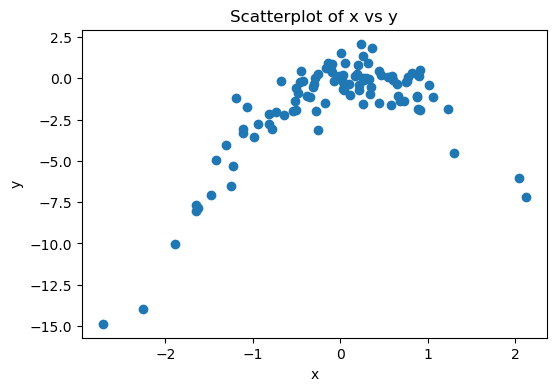

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatterplot of x vs y")
plt.show()

In [17]:
def loocv_error(degree):
    X = np.column_stack([x**i for i in range(1, degree+1)])
    loo = LeaveOneOut()
    errors = []

    for train, test in loo.split(X):
        X_train = sm.add_constant(X[train])
        X_test = sm.add_constant(X[test], has_constant='add')
        model = sm.OLS(y[train], X_train).fit()
        pred = model.predict(X_test)
        errors.append((y[test][0] - pred[0])**2)

    return np.mean(errors)

print("\n" + "="*60)
print("LOOCV Errors")
print("="*60)

np.random.seed(1)
results = pd.DataFrame({"Degree":[1,2,3,4], "LOOCV Error":[loocv_error(d) for d in [1,2,3,4]]})
print(results)


LOOCV Errors
   Degree  LOOCV Error
0       1     6.633030
1       2     1.122937
2       3     1.301797
3       4     1.332394


In [18]:
print("\n" + "="*60)
print("LOOCV Repeated with Different Seed")
print("="*60)

np.random.seed(25)
results2 = pd.DataFrame({"Degree":[1,2,3,4], "LOOCV Error":[loocv_error(d) for d in [1,2,3,4]]})
print(results2)


LOOCV Repeated with Different Seed
   Degree  LOOCV Error
0       1     6.633030
1       2     1.122937
2       3     1.301797
3       4     1.332394


The LOOCV errors are identical to those obtained before with a different split/seed. Unlike validation set or k-fold cross-validation, LOOCV always uses exactly the same training and test splits, with each observation serving once as the test observation. Therefore, changing the random seed has no effect on the LOOCV estimates.

In [19]:
print("\n" + "="*60)
print("Best Model")
print("="*60)

best = results.loc[results["LOOCV Error"].idxmin()]
print(best)


Best Model
Degree         2.000000
LOOCV Error    1.122937
Name: 1, dtype: float64


In [20]:
print("\n" + "="*60)
print("Least Squares Models")
print("="*60)

for degree in [1,2,3,4]:
    X = np.column_stack([x**i for i in range(1, degree+1)])
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    print("\n")
    print("-"*60)
    print(f"Polynomial Degree {degree}")
    print("-"*60)
    print(model.summary())


Least Squares Models


------------------------------------------------------------
Polynomial Degree 1
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     45.60
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           1.04e-09
Time:                        21:51:56   Log-Likelihood:                -230.83
No. Observations:                 100   AIC:                             465.7
Df Residuals:                      98   BIC:                             470.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t 

The quadratic model is the correct model because the data were generated from Y = X − 2X^2 + ε. In the quadratic regression, both X and X^2 are statistically significant. In the cubic model, the X^3 term is not significant, indicating that a cubic term is unnecessary. In the quartic model, the X^4 term appears statistically significant (p ≈ 0.023), likely due to sampling variability and its strong relationship with X^2, not because the true model contains a quartic component. This agrees with the LOOCV results, which show that the quadratic model has the lowest test error, while the cubic and quartic models do not improve predictive performance. Thus, the quadratic model provides the best balance between model complexity and prediction accuracy.

# Applied Exercise 9 - Boston Housing Data: Bootstrap

#### Objective of this exercise is to apply bootstrap to find measures of central tendency

In [22]:
Boston = load_data("Boston")
medv = Boston["medv"]
rng = np.random.default_rng(1)
mu_hat = medv.mean()

print("\nEstimate of population mean")
print("-" * 65)
print(f"mu_hat = {mu_hat:.4f}")

n = len(medv)
sample_sd = medv.std(ddof=1)
se_mean = sample_sd / np.sqrt(n)

print("\nStandard Error of the Mean")
print("-" * 65)
print(f"Number of observations = {n}")
print(f"Sample standard deviation = {sample_sd:.4f}")
print(f"SE(mu_hat) = {se_mean:.4f}")

B = 10000
bootstrap_means = np.empty(B)

for i in range(B):
    sample = rng.choice(medv, size=n, replace=True)
    bootstrap_means[i] = sample.mean()

bootstrap_se_mean = bootstrap_means.std(ddof=1)
print("\nBootstrap Standard Error of the Mean")
print("-" * 65)
print(f"Bootstrap SE = {bootstrap_se_mean:.4f}")
print(f"Formula SE   = {se_mean:.4f}")


Estimate of population mean
-----------------------------------------------------------------
mu_hat = 22.5328

Standard Error of the Mean
-----------------------------------------------------------------
Number of observations = 506
Sample standard deviation = 9.1971
SE(mu_hat) = 0.4089

Bootstrap Standard Error of the Mean
-----------------------------------------------------------------
Bootstrap SE = 0.4098
Formula SE   = 0.4089


The mean obtained by bootstrap is very close to the standard error of 0.4089 obtained using the formula. Therefore, the bootstrap provides a very similar estimate of the uncertainty in the sample mean.

In [23]:
lower_mean = mu_hat - 2 * bootstrap_se_mean
upper_mean = mu_hat + 2 * bootstrap_se_mean

lower_formula = mu_hat - 2 * se_mean
upper_formula = mu_hat + 2 * se_mean

print("\n95% Confidence Interval for Mean")
print("-" * 65)
print(f"Bootstrap CI: ({lower_mean:.4f}, {upper_mean:.4f})")
print(f"Formula CI:   ({lower_formula:.4f}, {upper_formula:.4f})")


95% Confidence Interval for Mean
-----------------------------------------------------------------
Bootstrap CI: (21.7132, 23.3524)
Formula CI:   (21.7151, 23.3505)


In [24]:
mu_med = medv.median()
print("\nEstimate of Population Median")
print("-" * 65)
print(f"mu_med = {mu_med:.4f}")

bootstrap_medians = np.empty(B)

for i in range(B):
    sample = rng.choice(medv, size=n, replace=True)
    bootstrap_medians[i] = np.median(sample)

bootstrap_se_median = bootstrap_medians.std(ddof=1)
print("\nBootstrap Standard Error of Median")
print("-" * 65)
print(f"Median = {mu_med:.4f}")
print(f"Bootstrap SE of median = {bootstrap_se_median:.4f}")


Estimate of Population Median
-----------------------------------------------------------------
mu_med = 21.2000

Bootstrap Standard Error of Median
-----------------------------------------------------------------
Median = 21.2000
Bootstrap SE of median = 0.3813


In [25]:
mu_01 = np.percentile(medv, 10)

print("\nEstimate of Tenth Percentile")
print("-" * 65)
print(f"mu_0.1 = {mu_01:.4f}")

bootstrap_percentiles = np.empty(B)

for i in range(B):
    sample = rng.choice(medv, size=n, replace=True)
    bootstrap_percentiles[i] = np.percentile(sample, 10)

bootstrap_se_01 = bootstrap_percentiles.std(ddof=1)
print("\nBootstrap Standard Error of Tenth Percentile")
print("-" * 65)
print(f"Tenth percentile = {mu_01:.4f}")
print(f"Bootstrap SE = {bootstrap_se_01:.4f}")


Estimate of Tenth Percentile
-----------------------------------------------------------------
mu_0.1 = 12.7500

Bootstrap Standard Error of Tenth Percentile
-----------------------------------------------------------------
Tenth percentile = 12.7500
Bootstrap SE = 0.4999


This means that approximately 10% of the observations have a medv value of 12.75 or less, while approximately 90% have values above 12.75. Since medv is measured in thousands of dollars, this corresponds to approximately $12,750.